# Hierarchical Intrusion Detection from Multi-Class PMU Data

This notebook implements the final hierarchical intrusion detection system using
the released multi-class PMU dataset (37 available scenarios).
All models are trained from the same dataset using task-specific labels derived
from the `marker` attribute.

In [116]:
# ============================================================
# Section 0 — Imports, Settings, and Utility Functions
# ============================================================

# ----------------------------
# Core libraries
# ----------------------------
import pandas as pd
import numpy as np

# ----------------------------
# Reproducibility
# ----------------------------
np.random.seed(42)

# ----------------------------
# Display settings (optional)
# ----------------------------
pd.set_option("display.max_columns", 200)

# ----------------------------
# Visualization libraries
# ----------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------
# Scikit-learn utilities
# ----------------------------
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# ----------------------------
# Model persistence
# ----------------------------
import joblib

In [117]:
# ============================================================
# Section 1 - Utility Function — Confusion Matrix Plot
# ============================================================
def plot_confusion_matrix(
    y_true,
    y_pred,
    class_names,
    title="Confusion Matrix",
    figsize=(7, 5)
):
    """
    Plot a confusion matrix heatmap with counts.

    Parameters:
    - y_true: true labels
    - y_pred: predicted labels
    - class_names: list of class names (order must match labels)
    - title: plot title
    - figsize: figure size
    """

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=figsize)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=True,
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [118]:
# ============================================================
# Section 2 — Load Dataset
# ============================================================

import pandas as pd

# ------------------------------------------------------------
# Load full dataset
# ------------------------------------------------------------
DATA_PATH = "../data/merged/multi_class_dataset_clean_FULL.csv"
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)

# ------------------------------------------------------------
# Feature / label separation
# ------------------------------------------------------------
FEATURE_COLS = [
    c for c in df.columns
    if c not in ["marker", "label", "label_name"]
]

X_all = df[FEATURE_COLS]
y_marker = df["marker"]

print("Number of features:", len(FEATURE_COLS))
print("Number of unique scenarios:", y_marker.nunique())
print("Scenario IDs (min → max):", y_marker.min(), "→", y_marker.max())

Dataset shape: (78377, 133)
Number of features: 132
Number of unique scenarios: 37
Scenario IDs (min → max): 1 → 41


In [119]:
# ============================================================
# Section 3 — Hierarchical Label Grouping
# ============================================================
# This section defines the hierarchical label structure used
# throughout training and inference.
#
# Design choice:
# - Non-attack samples are grouped into PHYSICAL FAMILIES
# - Attack samples preserve their ORIGINAL SCENARIO IDs
#
# Hierarchy:
#   M1: Attack vs Non-Attack
#   M2: Non-Attack Physical Families
#   M3: Attack Family
#   M4–M6: Attack Subtypes (scenario-level)
# ============================================================


# ------------------------------------------------------------
# Scenario Groups
# ------------------------------------------------------------

# ---- Non-Attack scenarios (physical layer abnormalities) ----
SLG_IDS     = [1, 2, 3, 4, 5, 6]     # Natural faults (short/long line-ground, etc.)
MAINT_IDS   = [13, 14]              # Maintenance / switching events
NORMAL_IDS  = [41]                  # Normal operation (no disturbance)

NON_ATTACK_IDS = SLG_IDS + MAINT_IDS + NORMAL_IDS


# ---- Attack scenario groups ----
DI_IDS  = [7, 8, 9, 10, 11, 12]              # Data Injection attacks
RT_IDS  = [15, 16, 17, 18, 19, 20]           # Remote Tripping attacks
RSC_IDS = [21, 22, 23, 24, 25, 26, 27, 28,
           29, 30, 35, 36, 37, 38, 39, 40]   # Relay Setting Change attacks


# ------------------------------------------------------------
# M1 — Attack vs Non-Attack
# ------------------------------------------------------------
# Output:
#   0 = Attack
#   1 = Non-Attack
def map_M1(marker):
    return 1 if marker in NON_ATTACK_IDS else 0


# ------------------------------------------------------------
# M2 — Non-Attack Physical Families (FINAL OUTPUT)
# ------------------------------------------------------------
# Output classes:
# 0 = SLG Faults
# 1 = Line Maintenance
# 2 = Normal Operation
def map_M2(marker):
    if marker in SLG_IDS:
        return 0
    elif marker in MAINT_IDS:
        return 1
    elif marker in NORMAL_IDS:
        return 2
    else:
        return None


# Human-readable labels for reporting and plots
M2_LABELS = {
    0: "SLG Faults",
    1: "Line Maintenance",
    2: "Normal Operation"
}


# ------------------------------------------------------------
# M3 — Attack Family Classification
# ------------------------------------------------------------
# Output:
#   0 = Data Injection
#   1 = Remote Tripping
#   2 = Relay Setting Change
def map_M3(marker):
    if marker in DI_IDS:
        return 0
    elif marker in RT_IDS:
        return 1
    elif marker in RSC_IDS:
        return 2
    else:
        return None


# ------------------------------------------------------------
# M4 — Data Injection Subtypes (scenario-level)
# ------------------------------------------------------------
DI_MAP = {k: i for i, k in enumerate(DI_IDS)}
DI_INV_MAP = {i: k for i, k in enumerate(DI_IDS)}

def map_M4(marker):
    return DI_MAP.get(marker, None)


# ------------------------------------------------------------
# M5 — Remote Tripping Subtypes (scenario-level)
# ------------------------------------------------------------
RT_MAP = {k: i for i, k in enumerate(RT_IDS)}
RT_INV_MAP = {i: k for i, k in enumerate(RT_IDS)}

def map_M5(marker):
    return RT_MAP.get(marker, None)


# ------------------------------------------------------------
# M6 — Relay Setting Change Subtypes (scenario-level)
# ------------------------------------------------------------
RSC_MAP = {k: i for i, k in enumerate(RSC_IDS)}
RSC_INV_MAP = {i: k for i, k in enumerate(RSC_IDS)}

def map_M6(marker):
    return RSC_MAP.get(marker, None)

In [120]:
# ============================================================
# Section 4 — Train M1
# ============================================================
# ------------------------------------------------------------
# Labels
# 0 = Attack, 1 = Non-Attack
# ------------------------------------------------------------
y_M1 = df["marker"].apply(map_M1)
X_M1 = df[FEATURE_COLS]

# ------------------------------------------------------------
# Train / Validation / Test split
# 60% / 20% / 20%
# ------------------------------------------------------------
X_temp, X_test_M1, y_temp, y_test_M1 = train_test_split(
    X_M1,
    y_M1,
    test_size=0.20,
    random_state=42,
    stratify=y_M1
)

X_train_M1, X_val_M1, y_train_M1, y_val_M1 = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,   # 0.25 × 0.8 = 0.20
    random_state=42,
    stratify=y_temp
)

print("M1 class distribution:")
print("Train:\n", y_train_M1.value_counts(normalize=True))
print("Validation:\n", y_val_M1.value_counts(normalize=True))
print("Test:\n", y_test_M1.value_counts(normalize=True))

# ------------------------------------------------------------
# Base model (Logistic Regression)
# ------------------------------------------------------------
M1_base = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        n_jobs=-1,
        random_state=42
    ))
])

# ------------------------------------------------------------
# Calibrated M1 (Platt scaling, cv=3)
# ------------------------------------------------------------
M1 = CalibratedClassifierCV(
    M1_base,
    method="sigmoid",
    cv=3
)

# ------------------------------------------------------------
# Train M1
# ------------------------------------------------------------
M1.fit(X_train_M1, y_train_M1)

print("✅ M1 training complete")

M1 class distribution:
Train:
 marker
0    0.710197
1    0.289803
Name: proportion, dtype: float64
Validation:
 marker
0    0.710194
1    0.289806
Name: proportion, dtype: float64
Test:
 marker
0    0.710194
1    0.289806
Name: proportion, dtype: float64
✅ M1 training complete


M1 Validation Classification Report:
              precision    recall  f1-score   support

      Attack       0.72      0.98      0.83     11133
  Non-Attack       0.55      0.06      0.10      4543

    accuracy                           0.71     15676
   macro avg       0.64      0.52      0.47     15676
weighted avg       0.67      0.71      0.62     15676



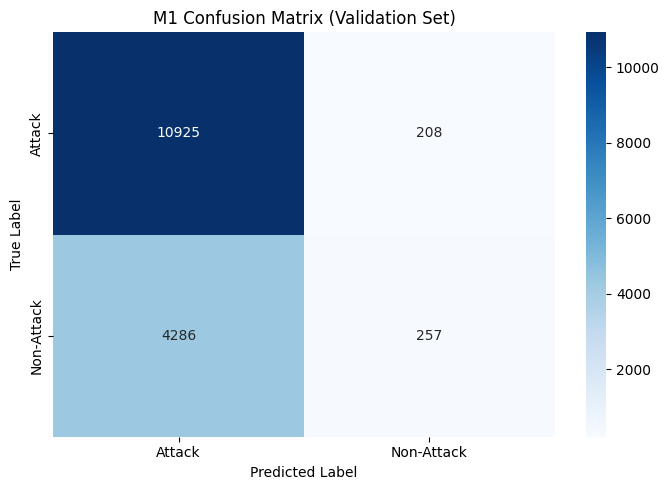

In [121]:
# ============================================================
# Section 5 — Validate M1 (Routing Gate)
# ============================================================

# Predict on validation set
y_val_pred = M1.predict(X_val_M1)

# Classification report (sanity check)
print("M1 Validation Classification Report:")
print(classification_report(
    y_val_M1,
    y_val_pred,
    target_names=["Attack", "Non-Attack"]
))

# Confusion matrix using utility function
plot_confusion_matrix(
    y_true=y_val_M1,
    y_pred=y_val_pred,
    class_names=["Attack", "Non-Attack"],
    title="M1 Confusion Matrix (Validation Set)"
)

M2 dataset size: (22714, 133)

M2 class distribution:
marker
0    15000
1     3309
2     4405
Name: count, dtype: int64
✅ M2 training complete

M2 Classification Report:
                  precision    recall  f1-score   support

      SLG Faults       0.94      0.99      0.96      3000
Line Maintenance       0.94      0.76      0.84       662
Normal Operation       0.99      0.97      0.98       881

        accuracy                           0.95      4543
       macro avg       0.96      0.91      0.93      4543
    weighted avg       0.95      0.95      0.95      4543



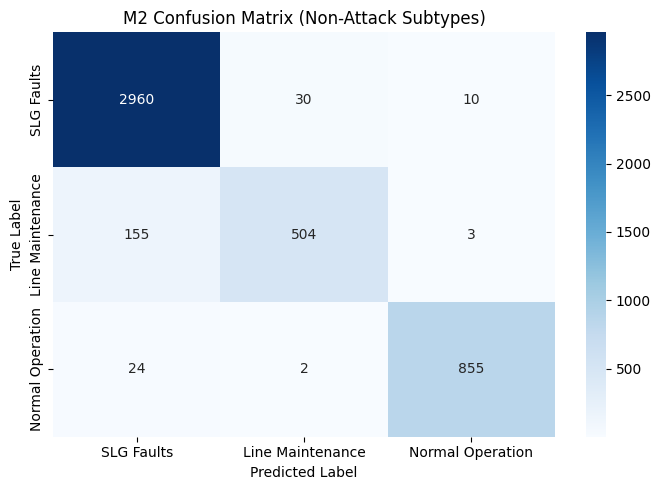

In [122]:
# ============================================================
# Section 6 — Train M2 (Non-Attack Physical Families)
# ============================================================
# ------------------------------------------------------------
# Prepare M2 dataset (non-attack samples only)
# ------------------------------------------------------------
df_M2 = df[df["marker"].isin(NON_ATTACK_IDS)].copy()
print("M2 dataset size:", df_M2.shape)

X_M2 = df_M2[FEATURE_COLS]
y_M2 = df_M2["marker"].apply(map_M2)

# Sanity check
assert y_M2.isna().sum() == 0, "❌ Unmapped labels in M2"

print("\nM2 class distribution:")
print(y_M2.value_counts().sort_index())

# ------------------------------------------------------------
# Train / Test split (80 / 20)
# ------------------------------------------------------------
X_train_M2, X_test_M2, y_train_M2, y_test_M2 = train_test_split(
    X_M2,
    y_M2,
    test_size=0.20,
    random_state=42,
    stratify=y_M2
)

# ------------------------------------------------------------
# Train Random Forest (no calibration)
# ------------------------------------------------------------
M2 = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

M2.fit(X_train_M2, y_train_M2)

print("✅ M2 training complete")

# ------------------------------------------------------------
# Evaluate M2 (test set only — reporting)
# ------------------------------------------------------------
y_test_pred_M2 = M2.predict(X_test_M2)

print("\nM2 Classification Report:")
print(classification_report(
    y_test_M2,
    y_test_pred_M2,
    target_names=[
        "SLG Faults",
        "Line Maintenance",
        "Normal Operation"
    ]
))

# ------------------------------------------------------------
# Confusion Matrix (using shared utility)
# ------------------------------------------------------------
plot_confusion_matrix(
    y_true=y_test_M2,
    y_pred=y_test_pred_M2,
    class_names=[
        "SLG Faults",
        "Line Maintenance",
        "Normal Operation"
    ],
    title="M2 Confusion Matrix (Non-Attack Subtypes)"
)

M3 total samples: 55663
M3 class distribution:
marker
0     9582
1     8737
2    37344
Name: count, dtype: int64

M3 dataset split:
Training samples: 44530
Test samples:     11133

✅ M3 training complete

M3 Classification Report:
                      precision    recall  f1-score   support

      Data Injection       0.92      0.79      0.85      1917
     Remote Tripping       0.91      0.79      0.84      1747
Relay Setting Change       0.92      0.98      0.95      7469

            accuracy                           0.92     11133
           macro avg       0.92      0.85      0.88     11133
        weighted avg       0.92      0.92      0.91     11133



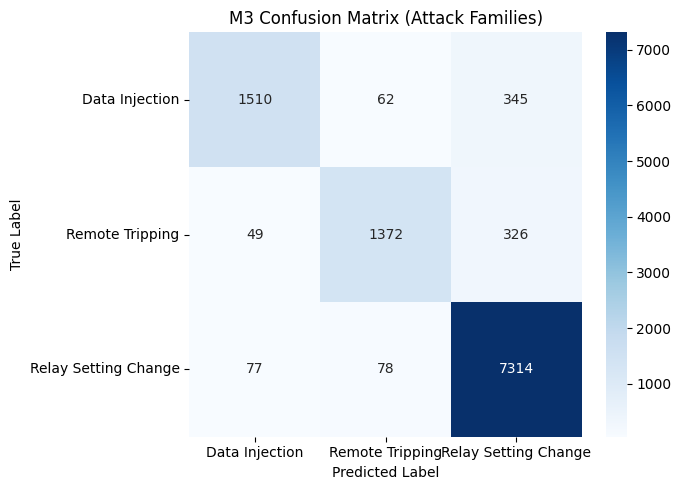

In [128]:
# ============================================================
# Section 7 - M3 — Attack Family Classifier
# ============================================================

# M3 labels:
# 0 = Data Injection
# 1 = Remote Tripping
# 2 = Relay Setting Change

# ----------------------------
# Prepare M3 dataset (ATTACK ONLY)
# ----------------------------
df_M3 = df[~df["marker"].isin(NON_ATTACK_IDS)].copy()

X_M3 = df_M3[FEATURE_COLS]
y_M3 = df_M3["marker"].apply(map_M3)

print("M3 total samples:", len(X_M3))
print("M3 class distribution:")
print(y_M3.value_counts().sort_index())

# ----------------------------
# Train / Test split (80 / 20)
# ----------------------------
X_train_M3, X_test_M3, y_train_M3, y_test_M3 = train_test_split(
    X_M3,
    y_M3,
    test_size=0.20,
    random_state=42,
    stratify=y_M3
)

print("\nM3 dataset split:")
print(f"Training samples: {X_train_M3.shape[0]}")
print(f"Test samples:     {X_test_M3.shape[0]}")

# ----------------------------
# Train Random Forest
# ----------------------------
M3 = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

M3.fit(X_train_M3, y_train_M3)

print("\n✅ M3 training complete")

# ----------------------------
# Evaluation
# ----------------------------
y_pred_M3 = M3.predict(X_test_M3)

print("\nM3 Classification Report:")
print(classification_report(
    y_test_M3,
    y_pred_M3,
    target_names=[
        "Data Injection",
        "Remote Tripping",
        "Relay Setting Change"
    ]
))

plot_confusion_matrix(
    y_true=y_test_M3,
    y_pred=y_pred_M3,
    class_names=[
        "Data Injection",
        "Remote Tripping",
        "Relay Setting Change"
    ],
    title="M3 Confusion Matrix (Attack Families)"
)

M4 total samples: 9582
M4 class distribution:
marker
0    1423
1    1257
2    1269
3    1753
4    1917
5    1963
Name: count, dtype: int64

M4 dataset split:
Training samples: 7665
Test samples:     1917

✅ M4 training complete

M4 Classification Report:
              precision    recall  f1-score   support

DI L1 10–19%       0.78      0.84      0.81       285
DI L1 20–79%       0.83      0.84      0.84       251
DI L1 80–90%       0.86      0.79      0.82       254
DI L2 10–19%       0.92      0.89      0.91       351
DI L2 20–79%       0.92      0.89      0.91       383
DI L2 80–90%       0.89      0.93      0.91       393

    accuracy                           0.87      1917
   macro avg       0.87      0.86      0.87      1917
weighted avg       0.87      0.87      0.87      1917



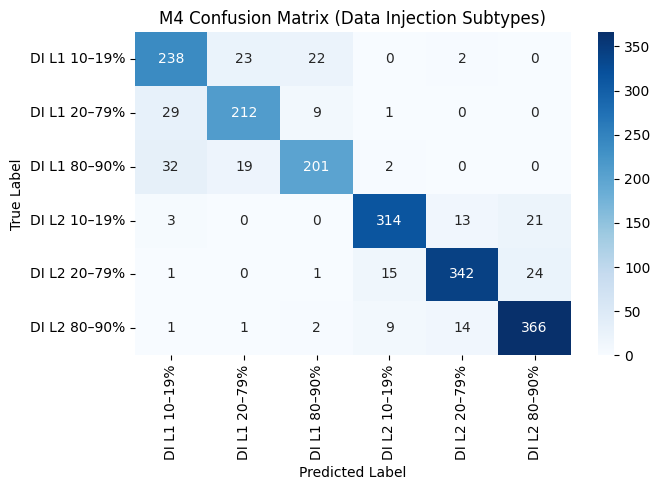

In [129]:
# ================================
# Section 8 - M4 Data Injection Subtype Classifier
# ================================

# ----------------------------
# Human-readable labels
# ----------------------------
DI_TARGET_NAMES = [
    "DI L1 10–19%",
    "DI L1 20–79%",
    "DI L1 80–90%",
    "DI L2 10–19%",
    "DI L2 20–79%",
    "DI L2 80–90%"
]

# ----------------------------
# Prepare M4 dataset
# ----------------------------
df_M4 = df[df["marker"].isin(DI_IDS)].copy()

X_M4 = df_M4[FEATURE_COLS]
y_M4 = df_M4["marker"].apply(map_M4)

print("M4 total samples:", len(X_M4))
print("M4 class distribution:")
print(y_M4.value_counts().sort_index())

# ----------------------------
# Train / Test split (80 / 20)
# ----------------------------
X_train_M4, X_test_M4, y_train_M4, y_test_M4 = train_test_split(
    X_M4,
    y_M4,
    test_size=0.20,
    random_state=42,
    stratify=y_M4
)

print("\nM4 dataset split:")
print(f"Training samples: {X_train_M4.shape[0]}")
print(f"Test samples:     {X_test_M4.shape[0]}")

# ----------------------------
# Train Random Forest
# ----------------------------
M4 = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

M4.fit(X_train_M4, y_train_M4)

print("\n✅ M4 training complete")

# ----------------------------
# Evaluation
# ----------------------------
y_pred_M4 = M4.predict(X_test_M4)

print("\nM4 Classification Report:")
print(classification_report(y_test_M4, y_pred_M4, target_names=DI_TARGET_NAMES))

plot_confusion_matrix(
    y_true=y_test_M4,
    y_pred=y_pred_M4,
    class_names=DI_TARGET_NAMES,
    title="M4 Confusion Matrix (Data Injection Subtypes)"
)

M5 total samples: 8737
M5 class distribution:
marker
0    1363
1    1354
2    1308
3    1250
4    1945
5    1517
Name: count, dtype: int64

M5 dataset split:
Training samples: 6989
Test samples:     1748

✅ M5 training complete

M5 Classification Report:
              precision    recall  f1-score   support

       RT R1       0.89      0.91      0.90       273
       RT R2       0.94      0.90      0.92       271
       RT R3       0.93      0.94      0.93       262
       RT R4       0.94      0.92      0.93       250
  RT R1 & R2       0.90      0.93      0.92       389
  RT R3 & R4       0.93      0.93      0.93       303

    accuracy                           0.92      1748
   macro avg       0.92      0.92      0.92      1748
weighted avg       0.92      0.92      0.92      1748



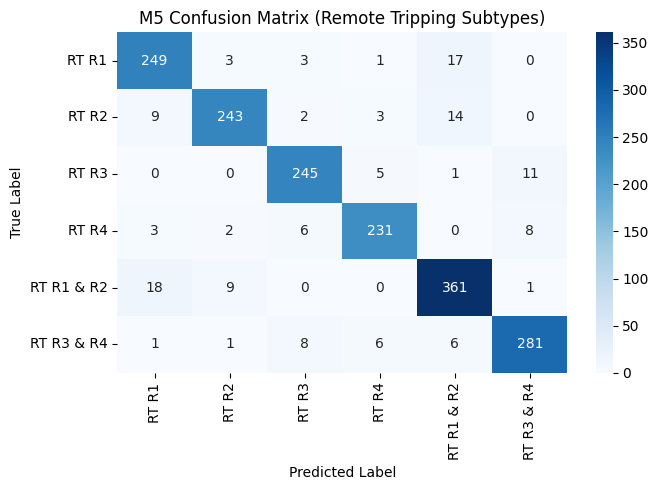

In [130]:
# ====================================================
# Section 9 - M5 — Remote Tripping Subtype Classifier
# ====================================================

# ----------------------------
# Human-readable labels
# ----------------------------

RT_TARGET_NAMES = [
    "RT R1",
    "RT R2",
    "RT R3",
    "RT R4",
    "RT R1 & R2",
    "RT R3 & R4"
]
# ----------------------------
# Prepare M5 dataset
# ----------------------------
df_M5 = df[df["marker"].isin(RT_IDS)].copy()

X_M5 = df_M5[FEATURE_COLS]
y_M5 = df_M5["marker"].apply(map_M5)

print("M5 total samples:", len(X_M5))
print("M5 class distribution:")
print(y_M5.value_counts().sort_index())

# ----------------------------
# Train / Test split (80 / 20)
# ----------------------------
X_train_M5, X_test_M5, y_train_M5, y_test_M5 = train_test_split(
    X_M5,
    y_M5,
    test_size=0.20,
    random_state=42,
    stratify=y_M5
)

print("\nM5 dataset split:")
print(f"Training samples: {X_train_M5.shape[0]}")
print(f"Test samples:     {X_test_M5.shape[0]}")

# ----------------------------
# Train Random Forest
# ----------------------------
M5 = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

M5.fit(X_train_M5, y_train_M5)

print("\n✅ M5 training complete")

# ----------------------------
# Evaluation
# ----------------------------
y_pred_M5 = M5.predict(X_test_M5)

print("\nM5 Classification Report:")
print(classification_report(y_test_M5, y_pred_M5, target_names=RT_TARGET_NAMES))

plot_confusion_matrix(
    y_true=y_test_M5,
    y_pred=y_pred_M5,
    class_names=RT_TARGET_NAMES,
    title="M5 Confusion Matrix (Remote Tripping Subtypes)"
)


M6 total samples: 37344
M6 class distribution:
marker
0     1242
1     1320
2     2635
3     2040
4     2481
5     2099
6     1630
7     2061
8     2128
9     2368
10    4487
11    4685
12    2716
13    2306
14    1474
15    1672
Name: count, dtype: int64

M6 dataset split:
Training samples: 29875
Test samples:     7469

✅ M6 training complete

M6 Classification Report:
                         precision    recall  f1-score   support

      RSC R1 (L1 Fault)       0.82      0.69      0.75       248
    RSC R1 (High Fault)       0.83      0.73      0.78       264
     RSC R2 (Low Fault)       0.93      0.90      0.92       527
     RSC R2 (Mid Fault)       0.92      0.87      0.90       408
    RSC R2 (High Fault)       0.88      0.90      0.89       496
     RSC R3 (Low Fault)       0.84      0.88      0.86       420
     RSC R3 (Mid Fault)       0.90      0.87      0.89       326
    RSC R3 (High Fault)       0.97      0.85      0.91       412
     RSC R4 (Low Fault)       0.91      0

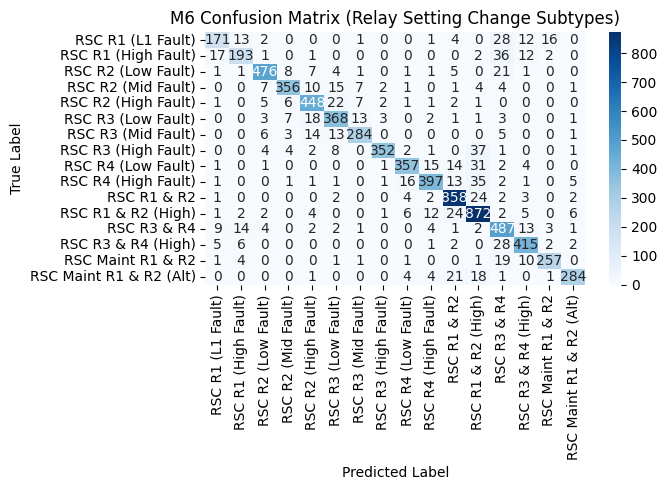

In [131]:
# ==========================================================
# Section 10 - M6 — Relay Setting Change Subtype Classifier
# ==========================================================

# ----------------------------
# Human-readable labels
# ----------------------------
RSC_TARGET_NAMES = [
    "RSC R1 (L1 Fault)",
    "RSC R1 (High Fault)",
    "RSC R2 (Low Fault)",
    "RSC R2 (Mid Fault)",
    "RSC R2 (High Fault)",
    "RSC R3 (Low Fault)",
    "RSC R3 (Mid Fault)",
    "RSC R3 (High Fault)",
    "RSC R4 (Low Fault)",
    "RSC R4 (High Fault)",
    "RSC R1 & R2",
    "RSC R1 & R2 (High)",
    "RSC R3 & R4",
    "RSC R3 & R4 (High)",
    "RSC Maint R1 & R2",
    "RSC Maint R1 & R2 (Alt)"
]
# ----------------------------
# Prepare M6 dataset
# ----------------------------
df_M6 = df[df["marker"].isin(RSC_IDS)].copy()

X_M6 = df_M6[FEATURE_COLS]
y_M6 = df_M6["marker"].apply(map_M6)

print("M6 total samples:", len(X_M6))
print("M6 class distribution:")
print(y_M6.value_counts().sort_index())

# ----------------------------
# Train / Test split (80 / 20)
# ----------------------------
X_train_M6, X_test_M6, y_train_M6, y_test_M6 = train_test_split(
    X_M6,
    y_M6,
    test_size=0.20,
    random_state=42,
    stratify=y_M6
)

print("\nM6 dataset split:")
print(f"Training samples: {X_train_M6.shape[0]}")
print(f"Test samples:     {X_test_M6.shape[0]}")

# ----------------------------
# Train Random Forest
# ----------------------------
M6 = RandomForestClassifier(
    n_estimators=400,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

M6.fit(X_train_M6, y_train_M6)

print("\n✅ M6 training complete")

# ----------------------------
# Evaluation
# ----------------------------
y_pred_M6 = M6.predict(X_test_M6)

print("\nM6 Classification Report:")
print(
    classification_report(
        y_test_M6,
        y_pred_M6,
        target_names=RSC_TARGET_NAMES
    )
)

plot_confusion_matrix(
    y_true=y_test_M6,
    y_pred=y_pred_M6,
    class_names=RSC_TARGET_NAMES,
    title="M6 Confusion Matrix (Relay Setting Change Subtypes)"
)


## 📊 Model Summary — Hierarchical IDS (M1–M6)

| Model | Role in Hierarchy | Algorithm | Classes | Training Samples | Data Split | Key Hyperparameters | Calibration | n_jobs |
|------|------------------|-----------|---------|------------------|------------|---------------------|-------------|--------|
| **M1** | Attack vs Non-Attack Gate | Logistic Regression | 2 | 62,701 | Train / Val / Test | max_iter=2000, class_weight=balanced | Yes (Sigmoid, CV=3) | -1 |
| **M2** | Non-Attack Physical Family | Random Forest | 3 | 18,171 | 80 / 20 | n_estimators=300, min_samples_leaf=2 | No | -1 |
| **M3** | Attack Family Router | Random Forest | 3 | 44,530 | 80 / 20 | n_estimators=300 | No | -1 |
| **M4** | Data Injection Subtypes | Random Forest | 6 | 7,665 | 80 / 20 | n_estimators=300 | No | -1 |
| **M5** | Remote Tripping Subtypes | Random Forest | 6 | 6,989 | 80 / 20 | n_estimators=300 | No | -1 |
| **M6** | Relay Setting Change Subtypes | Random Forest | 16 | 29,875 | 80 / 20 | n_estimators=400, min_samples_leaf=2 | No | -1 |

In [132]:
# ==========================================================
# Section 11 — Save Trained Models
# ==========================================================
import os
import joblib

os.makedirs("models", exist_ok=True)

joblib.dump(M1, "models/M1.joblib")
joblib.dump(M2, "models/M2.joblib")
joblib.dump(M3, "models/M3.joblib")
joblib.dump(M4, "models/M4.joblib")
joblib.dump(M5, "models/M5.joblib")
joblib.dump(M6, "models/M6.joblib")

['models/M6.joblib']